In [6]:
import pandas as pd
import numpy as np

# **Brakujące wartości**

**Brakujące wartości** to rekordy, które są nieobecne w zestawie danych.

**Przyczyny występowania**:
* Błąd człowieka podczas wprowadzania danych​

* Ochrona prywatności (dane wrażliwe)
* Brak odpowiedzi w ankietach

Problemy techniczne przy zbieraniu danych

Jest to jeden z **najczęściej występujących problemów** w analizie danych i kluczowy etap wstępnego przetwarzania (data preprocessing).

In [7]:
# Definicja DataFrame
df_student = pd.DataFrame({
    'imie': ['Anna', 'Piotr', 'Maria', 'Jan', 'Katarzyna', 'Tomasz', 'Magdalena', 'Paweł', 'Ewa', 'Michał'],
    'wiek': [20, 22, 21, np.nan, 23, 20, 22, np.nan, 21, 23],
    'ocena_matematyka': [4.5, np.nan, 5.0, 4.0, 3.5, 4.5, 5.0, 3.5, np.nan, 4.0],
    'ocena_fizyka': [5.0, 4.5, np.nan, 4.0, 4.5, np.nan, 5.0, 4.0, 4.5, np.nan],
    'ocena_informatyka': [4.0, 3.5, 4.5, np.nan, 5.0, 3.5, 4.5, 4.0, np.nan, 4.5],
    'miasto': ['Warszawa', 'Kraków', 'Wrocław', 'Poznań', 'Gdańsk', np.nan, 'Warszawa', 'Kraków', 'Wrocław', 'Poznań']
})

In [8]:
# 1. Sprawdzenie czy są brakujące wartości
print("1. Sprawdzenie brakujących wartości (True = brak):")
print(df_student.isnull())
# lub: df.isna()
print("\n" + "="*60 + "\n")

1. Sprawdzenie brakujących wartości (True = brak):
    imie   wiek  ocena_matematyka  ocena_fizyka  ocena_informatyka  miasto
0  False  False             False         False              False   False
1  False  False              True         False              False   False
2  False  False             False          True              False   False
3  False   True             False         False               True   False
4  False  False             False         False              False   False
5  False  False             False          True              False    True
6  False  False             False         False              False   False
7  False   True             False         False              False   False
8  False  False              True         False               True   False
9  False  False             False          True              False   False




In [9]:
# 2. Liczba brakujących wartości w każdej kolumnie
print("2. Liczba brakujących wartości w każdej kolumnie:")
print(df_student.isna().sum())
print("\n" + "="*60 + "\n")

2. Liczba brakujących wartości w każdej kolumnie:
imie                 0
wiek                 2
ocena_matematyka     2
ocena_fizyka         3
ocena_informatyka    2
miasto               1
dtype: int64




In [10]:
# 3. Procent brakujących wartości
print("3. Procent brakujących wartości w każdej kolumnie:")
print((df_student.isnull().sum() / len(df_student)) * 100)
print("\n" + "="*60 + "\n")

3. Procent brakujących wartości w każdej kolumnie:
imie                  0.0
wiek                 20.0
ocena_matematyka     20.0
ocena_fizyka         30.0
ocena_informatyka    20.0
miasto               10.0
dtype: float64




In [11]:
# 4. Całkowita liczba brakujących wartości
print("4. Całkowita liczba brakujących wartości w całym DataFrame:")
print(df_student.isnull().sum().sum())

4. Całkowita liczba brakujących wartości w całym DataFrame:
10


## **Rozwiązanie kwestii brakujących danych**

* **Usuwanie rekordów** zawierających brakujące wartości.
* **Ręczne uzupełnianie** brakujących wartości.
* Uzupełnianie **brakujących wartości wskaźnikami** tendencji centralnej, np.: średnią, medianą czy dominantą.
  * **Średniej** używamy w przypadku cech numerycznych,
  * **mediany** w cechach porządkowych,
  * **dominantę** (czyli najczęściej powtarzającą się wartość) umieszczamy w cechach kategorialnych.

Uzupełnianie **najbardziej prawdopodobną wartością** przy użyciu modeli uczenia maszynowego, takich jak regresja, drzewa decyzyjne czy algorytm KNN.

## **Czym jest NaN i dlaczego jest wyjątkowy?**

**NaN** (Not a Number) – specjalna wartość reprezentująca brakujące dane.

Dane mogą zawierać różne oznaczenia braków:
* Tekstowe: "NA", "N/A", "brak", "?", "-"

* Numeryczne: 0, -999, -1​

* Inne: puste stringi ""

In [12]:
df = pd.DataFrame({
    'A': [1, np.nan, 3],# ✓ NaN - brakująca wartość ​
    'B': [4, None, 6],  # ✓ None - też brakująca ​
    'C': [7, 0, 9],     # ✗ 0 - NIE jest brakująca! ​
    'D': ['x', '', 'z'] # ✗ '' - NIE jest brakująca! ​
})

In [13]:
df.isnull().sum()

,0
A,1
B,1
C,0
D,0


## **Usuwanie brakujących wartości**

Usuń wiersze z DOWOLNĄ brakującą wartością (domyślnie) ​

```
df.dropna()
df.dropna(how='any')
```

Usuń wiersze tylko gdy WSZYSTKIE wartości są brakujące df.dropna(how='all')
```
df.dropna(how="all")
```

Usuń kolumny z brakującymi wartościami
```
df.dropna(axis=1)
```

## **Uzupełnienie średnią lub modą​**

W pandas *dataFrame* możemy uzupełnić brakujące wartości za pomocą funkcji `fillna()`.
* Przyjmuje ona jedną wartość, która będzie wstawiana w pustych pozycjach lub zamiast wartości NaN.

Uzupełnia wszystkie brakujące wartości w kolumnie age średnią obliczoną z tejże kolumny

```data['age'] = data.age.fillna(data.age.mean())​```

Uzupełnia wszystkie brakujące wartości w kolumnie income medianą obliczoną z tejże kolumny

```data['income']=data.income.fillna(data.income.median())```

Zastępuje wszystkie brakujące wartości w kolumnie gender (kolumna kategorii) dominantą wyliczoną z tejże kolumny​

```data['gender']=data['gender'].fillna(data['gender'].mode()[0])​```

In [14]:
df_student["wiek"] = df_student.wiek.fillna(df_student.wiek.mean())
df_student

,imie,wiek,ocena_matematyka,ocena_fizyka,ocena_informatyka,miasto
0,Anna,20.0,4.5,5.0,4.0,Warszawa
1,Piotr,22.0,NaN,4.5,3.5,Kraków
2,Maria,21.0,5.0,NaN,4.5,Wrocław
3,Jan,21.5,4.0,4.0,NaN,Poznań
4,Katarzyna,23.0,3.5,4.5,5.0,Gdańsk
5,Tomasz,20.0,4.5,NaN,3.5,NaN
6,Magdalena,22.0,5.0,5.0,4.5,Warszawa
7,Paweł,21.5,3.5,4.0,4.0,Kraków
8,Ewa,21.0,NaN,4.5,NaN,Wrocław
9,Michał,23.0,4.0,NaN,4.5,Poznań


In [15]:
df_student["ocena_matematyka"] = df_student["ocena_matematyka"] .fillna(df_student["ocena_matematyka"] .mean())
df_student

,imie,wiek,ocena_matematyka,ocena_fizyka,ocena_informatyka,miasto
0,Anna,20.0,4.50,5.0,4.0,Warszawa
1,Piotr,22.0,4.25,4.5,3.5,Kraków
2,Maria,21.0,5.00,NaN,4.5,Wrocław
3,Jan,21.5,4.00,4.0,NaN,Poznań
4,Katarzyna,23.0,3.50,4.5,5.0,Gdańsk
5,Tomasz,20.0,4.50,NaN,3.5,NaN
6,Magdalena,22.0,5.00,5.0,4.5,Warszawa
7,Paweł,21.5,3.50,4.0,4.0,Kraków
8,Ewa,21.0,4.25,4.5,NaN,Wrocław
9,Michał,23.0,4.00,NaN,4.5,Poznań


In [16]:
df_student["miasto"] = df_student["miasto"].fillna(df_student["miasto"] .mode()[0])
df_student

,imie,wiek,ocena_matematyka,ocena_fizyka,ocena_informatyka,miasto
0,Anna,20.0,4.50,5.0,4.0,Warszawa
1,Piotr,22.0,4.25,4.5,3.5,Kraków
2,Maria,21.0,5.00,NaN,4.5,Wrocław
3,Jan,21.5,4.00,4.0,NaN,Poznań
4,Katarzyna,23.0,3.50,4.5,5.0,Gdańsk
5,Tomasz,20.0,4.50,NaN,3.5,Kraków
6,Magdalena,22.0,5.00,5.0,4.5,Warszawa
7,Paweł,21.5,3.50,4.0,4.0,Kraków
8,Ewa,21.0,4.25,4.5,NaN,Wrocław
9,Michał,23.0,4.00,NaN,4.5,Poznań


## **Obsługa brakujących danych jako stringi**

**Problem**
* Dane często zawierają braki zapisane jako tekst: **"NA", "N/A", "brak", "?", "-", "brak danych"**

* Pandas **nie rozpoznaje** ich automatycznie jako brakujące wartości!

### **Rozwiązanie 1: Wczytywanie z pliku CSV**

```
import pandas as pd

# Definiujemy listę wartości oznaczających brak
braki = ['NA', 'N/A', 'brak', 'brak danych', '?', '-', '']

# Wczytujemy plik z parametrem na_values
df = pd.read_csv('dane.csv', na_values=braki)

```

### **Rozwiązanie 2: Zamiana po wczytaniu**

```
# Zamieniamy wybrane stringi na NaN
df.replace(['NA', 'N/A', 'brak', 'brak danych', '?', '-'], np.nan, inplace=True)

# LUB dla konkretnej kolumny
df['kolumna'] = df['kolumna'].replace('brak', np.nan)
```

# **Zadanie**:

**Dane**: Plik *nieruchomosci.csv* - 45 ofert sprzedaży mieszkań

**Polecenie**

* Wczytaj dane i przeanalizuj problem brakujących wartości

* Zdecyduj, jak poradzić sobie z brakami w poszczególnych kolumnach

* Uzasadnij swoje wybory i zaimplementuj rozwiązanie

**Do przemyślenia**

* Jakie typy zmiennych masz w danych?
* Czy wszystkie braki powinny być obsłużone tak samo?
* Jakie konsekwencje niesie każda metoda?
* Jak to wpływa na eksploracyjną analizę danych?


              id  powierzchnia  liczba_pokoi  liczba_pieter       cena_m2    cena_total
count  45.000000     39.000000     45.000000      45.000000     45.000000  4.500000e+01
mean   23.000000     59.666667      2.688889       6.911111   9746.666667  6.590822e+05
std    13.133926     21.839526      0.924962       3.043788   2735.914348  1.502189e+05
min     1.000000      0.000000      1.000000       2.000000   -999.000000  4.250000e+05
25%    12.000000     51.500000      2.000000       4.000000   8900.000000  5.750000e+05
50%    23.000000     62.000000      3.000000       7.000000   9700.000000  6.480000e+05
75%    34.000000     72.000000      3.000000       9.000000  11000.000000  7.056000e+05
max    45.000000     95.000000      5.000000      15.000000  15000.000000  1.232000e+06




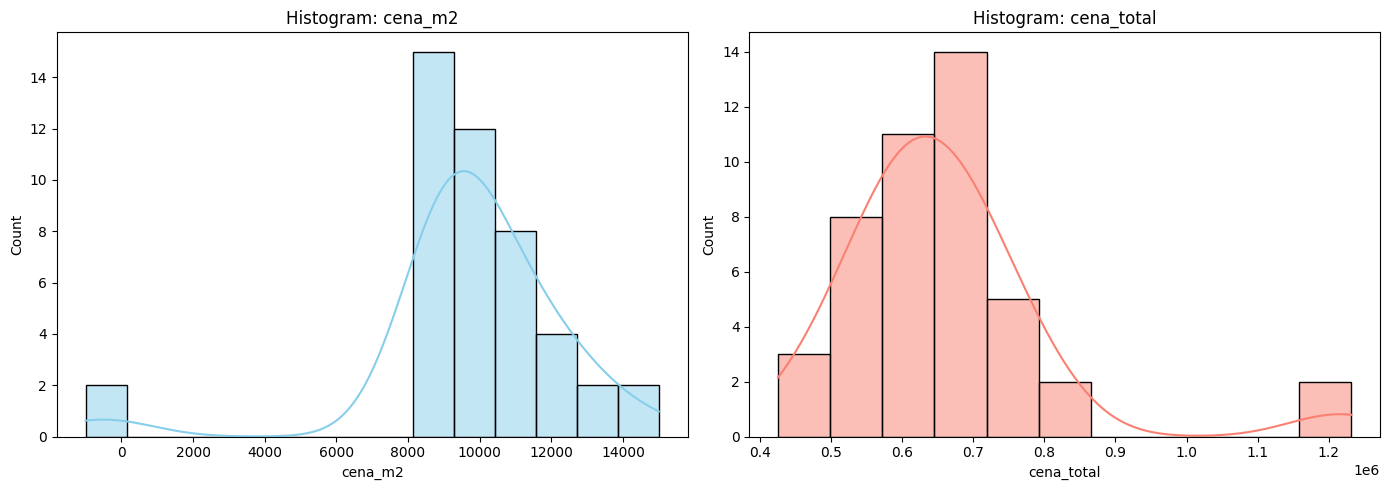

Liczba outlierów (cena_total) - Metoda IQR: 2
Liczba outlierów (cena_total) - Metoda Z-score: 2
Liczba outlierów (cena_total) - Metoda MAD: 2




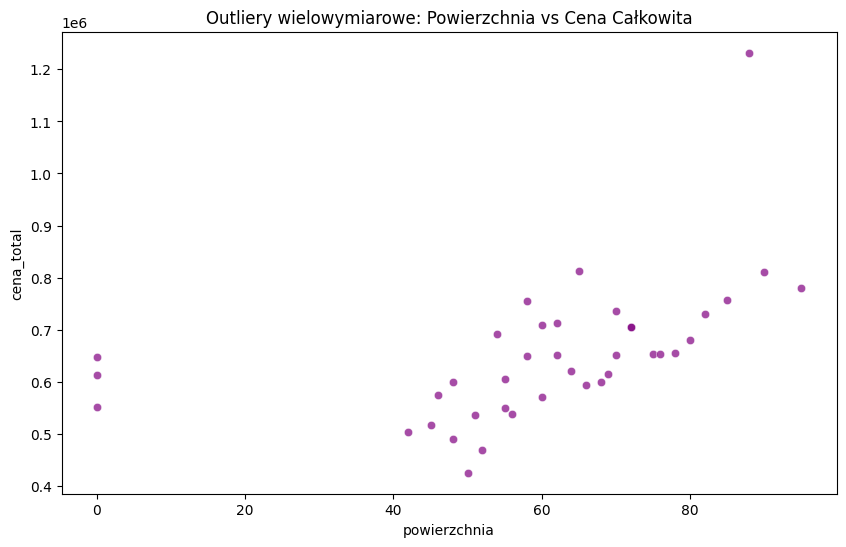

Podejrzane wartości w kolumnie rok_budowy:
 id  rok_budowy
  2         NaN
  9         NaN
 15         NaN
 21         NaN
 27         NaN
 36         NaN
 43         NaN


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('nieruchomosci.csv')

df['powierzchnia'] = df['powierzchnia'].astype(str).str.replace(r'[^\d.,]', '', regex=True).str.replace(',', '.')
df['powierzchnia'] = pd.to_numeric(df['powierzchnia'], errors='coerce')

print(df.describe().to_string())
print("\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['cena_m2'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Histogram: cena_m2')
sns.histplot(df['cena_total'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Histogram: cena_total')
plt.tight_layout()
plt.show()

Q1 = df['cena_total'].quantile(0.25)
Q3 = df['cena_total'].quantile(0.75)
IQR = Q3 - Q1
outliers_iqr = df[(df['cena_total'] < (Q1 - 1.5 * IQR)) | (df['cena_total'] > (Q3 + 1.5 * IQR))]

mean_cena = df['cena_total'].mean()
std_cena = df['cena_total'].std()
df['z_score'] = (df['cena_total'] - mean_cena) / std_cena
outliers_z = df[df['z_score'].abs() > 3]

median_cena = df['cena_total'].median()
mad = np.median(np.abs(df['cena_total'].dropna() - median_cena))
df['mad_score'] = np.abs(df['cena_total'] - median_cena) / (mad * 1.4826)
outliers_mad = df[df['mad_score'] > 3]

print(f"Liczba outlierów (cena_total) - Metoda IQR: {len(outliers_iqr)}")
print(f"Liczba outlierów (cena_total) - Metoda Z-score: {len(outliers_z)}")
print(f"Liczba outlierów (cena_total) - Metoda MAD: {len(outliers_mad)}")
print("\n")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='powierzchnia', y='cena_total', color='purple', alpha=0.7)
plt.title('Outliery wielowymiarowe: Powierzchnia vs Cena Całkowita')
plt.show()

df['rok_budowy'] = pd.to_numeric(df['rok_budowy'], errors='coerce')
podejrzany_rok = df[(df['rok_budowy'] < 1800) | (df['rok_budowy'] > 2028) | (df['rok_budowy'].isna())]
print("Podejrzane wartości w kolumnie rok_budowy:")
print(podejrzany_rok[['id', 'rok_budowy']].to_string(index=False))